<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_6_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caos I: la ecuación de Lorenz

## **Ejercicio 1)** Importando librerías

**1)** Importe las librerías `numpy` para operar con arrays, `scipy.signal` para analizar señales de datos y `matplotlib.pyplot` para graficar.

**2)** Suba el archivo "libreria" `ode.py` que fabricó en el práctico 4), e impórtelo.

In [ ]:
# a)
import numpy as np
#import scipy as sp
import scipy.signal as sgn
#import scipy.linalg as linalg
import matplotlib.pyplot as plt

In [ ]:
# b)
#import ode

def euler(f,x,t,h,p):
    """
    Calcula un paso de integración del método de Euler.

    Argumentos de entrada:

        f : R^n,R -> R^n
        x = x(t) : R^n
        t = tiempo : R
        h = paso de tiempo : R
        p = parametros : R^q

    Retorna aproximacion numérica de

        x(t+h) : R^n

    según el método de Euler.

    # Ejemplos:
    """
    return x+h*f(x,t,p)

def rk4(f,x,t,h,p):
    """
    Calcula un paso de integración del método de Runge Kutta orden 4.

    Argumentos de entrada:

        f : R^n -> R^n
        x = x(t) : R^n
        t = tiempo : R
        h = paso de tiempo : R
        p = parametros : R^q

    Retorna aproximacion numérica de

        x(t+h) : R^n

    según el método de Runge-Kutta de orden 4.

    # Ejemplos:
    """
    k1 = f(x,t,p)
    k2 = f(x+0.5*h*k1,t+0.5*h,p)
    k3 = f(x+0.5*h*k2,t+0.5*h,p)
    k4 = f(x+h*k3,t+h,p)
    return x+h*(k1+2.0*k2+2.0*k3+k4)/6.0

def integrador_ode(m,f,xa,a,b,k,p,c=lambda x,t,p:x):
    """
    Integra numéricamente la ODE

        dx/dt = f(x,t)

    sobre el intervalo t:[a,b] usando k pasos de integración y el método m, bajo condicion inicial x(a)=x0.
    No es necesario que a<b.

    Argumentos de entrada:

        m = metodo de integracion (ej. euler, rk2, etc.)
        f : R^n -> R^n
        xa = condicion inicial : R
        a = tiempo inicial : R
        b = tiempo final : R
        k = num. pasos de integracion : N
        p = parametros : R^q
        c = función condicionante : R^n,R,p -> R^n

    Retorna:

        t : R^{k+1} , t_j = a+j*h para j=0,1,...,k
        w : R^{n,k+1} , w_ij = x_i(t_j) para i=0,1,...,n-1 y j=0,1,...,k

    donde a+k*dt = b.
    """
    assert k>0
    n = len(xa)
    h = (b-a)/k
    w = np.zeros((n,k+1)) # Produce un array con forma y tipo especificada con los parametros,
                          # lleno de ceros. la forma puede ser espcificada con un entero o tupla (n,k+1)
    t = np.zeros(k+1)
    w[:,0] = xa           # actualiza la posicion inicial (columna de indice 0) de las variables con los valores
                          # de las condiciones iniciales
    t[0] = a              # actualiza la posicion cero con el valor del tiempo inicial

    for j in range(k):    #Aca se produce la iteración en j

        t[j+1] = t[j] + h                # iteracion tiempo
        w[:,j+1] = m(f,w[:,j],t[j],h,p)  # iteracion de w
        w[:,j+1] = c(w[:,j+1],t[j+1],p)  # condicion sobre w

    return t,w

## Ejercicio 2)

Considere el sistema de Ecuaciones Diferenciales Ordinarias de Lorenz

\begin{eqnarray}
\frac{dx}{dt} & = & s(y-x) \\
\frac{dy}{dt} & = & rx-y-xz \\
\frac{dz}{dt} & = & xy-bz
\end{eqnarray}

Sea $p=(s,r,b)$ el vector de parámetros.

**1)**
Usando el método de Runge-Kutta de orden 4, resuelva la ODE para las siguientes elecciones de las condiciones iniciales, de los parámetros y del intervalo de tiempo de integración:

&nbsp; &nbsp; **i)** $(x(0),y(0),z(0))=(1,0.5,0.1)$, $p=(10,0.5,8/3)$ y $t\in [0,10]$.

&nbsp; &nbsp; **ii)** $(x(0),y(0),z(0))=(1,0.5,0.1)$, $p=(10,10,8/3)$ y $t\in [0,20]$.

&nbsp; &nbsp; **iii)** $(x(0),y(0),z(0))=(1,0.5,0.1)$, $p=(10,28,8/3)$ y $t\in [0,50]$

**2)** Para cada caso calculado en el inciso **1)**, grafique, en un mismo gráfico, las curvas en función del tiempo $x(t)$ vs $t$, $y(t)$ vs $t$ y $z(t)$ vs $t$.

**3)**
Para cada caso calculado en el inciso **1)**, grafique paramétricamente en función del tiempo, y en 3 dimensiones, el vector que describe la trayectoria de la solución, i.e. grafique $(x(t),y(t),z(t))$ vs $t$.

In [ ]:
# 2)
# tenemos un sistema de 3 ecuaciones ordinarias
# por lo tanto, vamos a definir la f del lado derecho de la edo

def f(x, t, p):
  """
  sea un vector x=x[0], x[1], x[2]= x, y, z
  x' = s*(y-x) = p[0]*(x[1]-x[0]), con p[0]=s y que va en la primera coordenada
  y' = r*x-y-x*z = p[1]*x[0]-x[1]-x[0]*x[2], con p[1]=r y que va en la segunda coordenada
  z' = x*y-b*z = x[0]*x[1]-p[2]*x[2], con p[2]=b y que va en la tercera coordenada

  entonces p = (s, r, b)
  """
  return np.array([p[0]*(x[1]-x[0]), p[1]*x[0]-x[1]-x[0]*x[2], x[0]*x[1]-p[2]*x[2]])

In [ ]:
# 2.1.i)
"""
vamos a poner las condiciones iniciales y parametros para este caso
"""
xa = np.array([1, 0.5, 0.1])
p = np.array([10, 0.5, 8/3])
a = 0
b = 10

#tomamos paso de integracion h=0.1
h=0.1
# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

t, w = integrador_ode(rk4, f, xa, a, b, k, p)

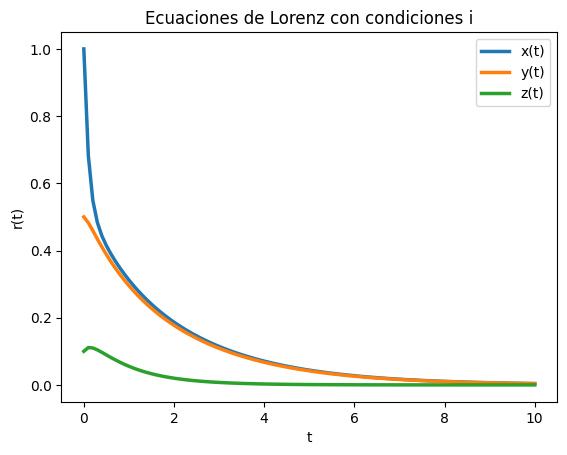

In [ ]:
# 2.2.i)
plt.plot(t, w[0,:], label="x(t)", linewidth=2.5)
plt.plot(t, w[1,:], label="y(t)", linewidth=2.5)
plt.plot(t, w[2,:], label="z(t)", linewidth=2.5)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title('Ecuaciones de Lorenz con condiciones i')
plt.legend()
plt.show()

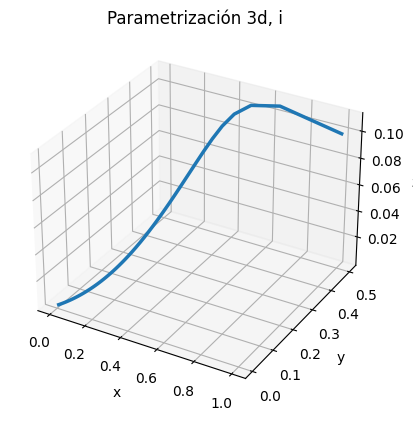

In [ ]:
# 2.3.i)
"""
ahora vamos a graficar en 3d
"""
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(w[0], w[1], w[2], linewidth=2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Parametrización 3d, i')
plt.show()

In [ ]:
# 2.1.ii)
"""
vamos a poner otros parametros para este caso (las condiciones iniciales no cambian)
"""
xa = np.array([1, 0.5, 0.1])
p = np.array([10, 10, 8/3])
a = 0
b = 20

#tomamos paso de integracion h=0.1
h=0.01
# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

t, w = integrador_ode(rk4, f, xa, a, b, k, p)

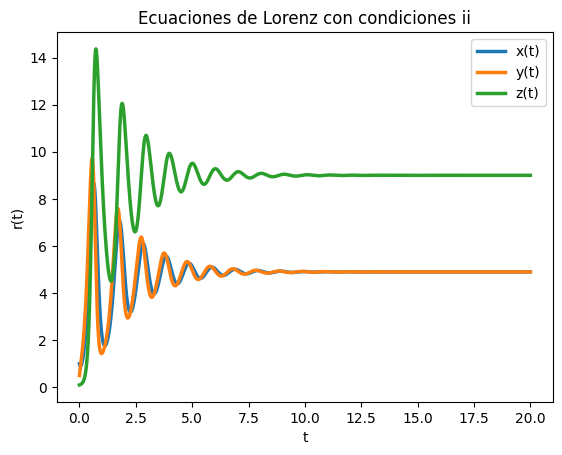

In [ ]:
# 2.2.ii)
plt.plot(t, w[0], label="x(t)", linewidth=2.5)
plt.plot(t, w[1,:], label="y(t)", linewidth=2.5)
plt.plot(t, w[2,:], label="z(t)", linewidth=2.5)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title('Ecuaciones de Lorenz con condiciones ii')
plt.legend()
plt.show()

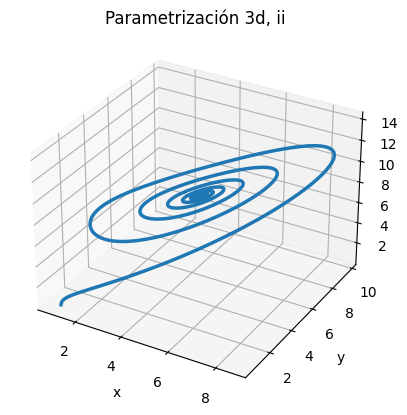

In [ ]:
# 2.3.ii)
"""
ahora vamos a graficar en 3d
"""
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(w[0], w[1], w[2], linewidth=2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Parametrización 3d, ii')
plt.show()

In [ ]:
# 2.1.iii)
"""
vamos a ver otros parametros distintos a los anteriores
"""
xa = np.array([1, 0.5, 0.1])
p = np.array([10, 28, 8/3])
a = 0
b = 50

#tomamos paso de integracion h=0.1
h=0.01
# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

t, w = integrador_ode(rk4, f, xa, a, b, k, p)

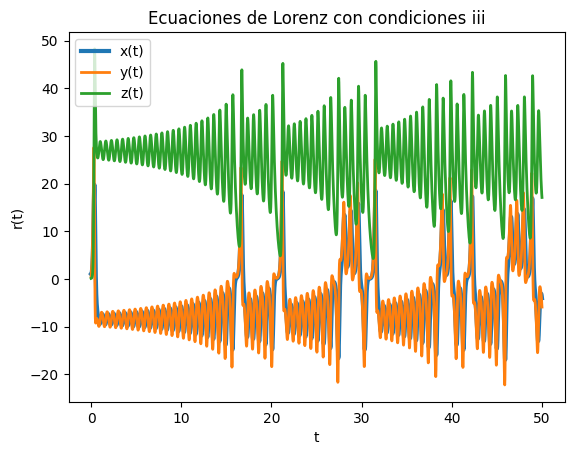

In [ ]:
# 2.2.iii)
plt.plot(t, w[0], label="x(t)", linewidth=3)
plt.plot(t, w[1,:], label="y(t)", linewidth=2)
plt.plot(t, w[2,:], label="z(t)", linewidth=2)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title('Ecuaciones de Lorenz con condiciones iii')
plt.legend()
plt.show()

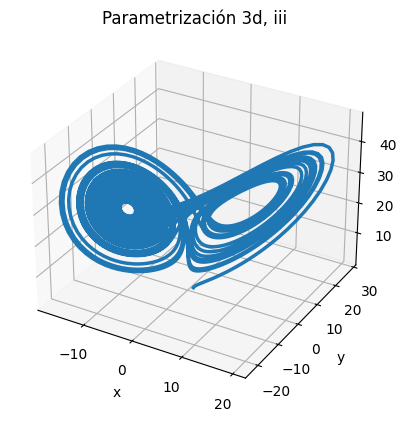

In [ ]:
# 2.3.iii)
"""
ahora vamos a graficar en 3d
"""
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(w[0], w[1], w[2], linewidth=2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Parametrización 3d, iii')
plt.show()

## Ejercicio 3)

**1)** Repita el caso **1.iii)** del ejercicio **2)**, para $t\in [0,300]$, y eliminando el transiente que se observa antes de "converger" al atractor.

**2)** Identifique los máximos locales de la curva $z(t)$ obtenida en el inciso **1)**, y enumérelos como $z_1,z_2,...,z_i,...,z_n$.

**3)** Grafique $z_{i+1}$ vs $z_i$ para todo $i\in\{1,2,...,n-1\}$.

In [ ]:
# 3.1)
"""
repetimos el 2.iii) pero con b=300
"""
xa = np.array([1, 0.5, 0.1])
p = np.array([10, 28, 8/3])
a = 0
b = 300

#tomamos paso de integracion h=0.1
h=0.01
# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

t, w = integrador_ode(rk4, f, xa, a, b, k, p)

# el transiente es el salto que pegan las funciones en t cercano a cero, para estar seguros que lo sacamos, vamos a sacar los primeros
# 70 puntos (o sea, arrancamos de 0.7)
t_trans = 70

t3 = t[t_trans:]
x3 = w[0][t_trans:]
y3 = w[1][t_trans:]
z3 = w[2][t_trans:]

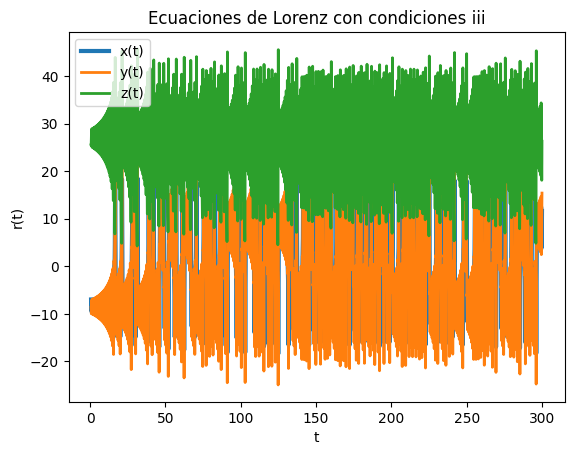

In [ ]:
"""
ploteamos las funciones wrt del t
"""
plt.plot(t3, x3, label="x(t)", linewidth=3)
plt.plot(t3, y3, label="y(t)", linewidth=2)
plt.plot(t3, z3, label="z(t)", linewidth=2)
plt.xlabel("t")
plt.ylabel("r(t)")
plt.title('Ecuaciones de Lorenz con condiciones iii')
plt.legend()
plt.show()

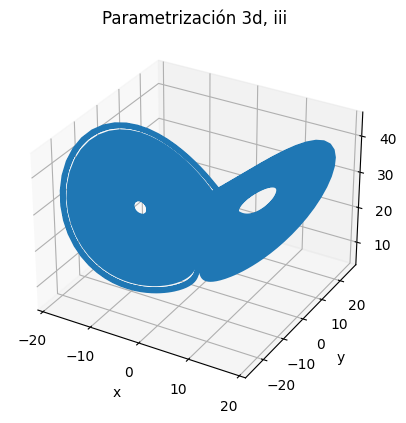

In [ ]:
"""
ploteamos la parametrizacion
"""
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(x3, y3, z3, linewidth=2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Parametrización 3d, iii')
plt.show()

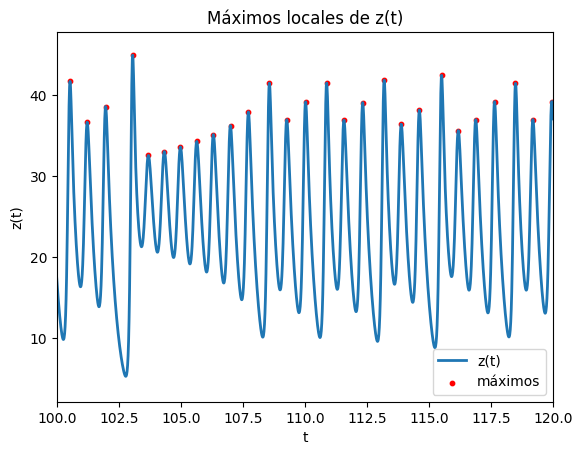

In [ ]:
# 3.2)
"""
Veamos ahora los máximos locales de la función z(t)
"""
# si z en i es mayor al siguiente y al anterior, entonces es un maximo local
max_t = [t3[i] for i in range(1, len(z3)-1) if z3[i]>z3[i-1] and z3[i]>z3[i+1]] # valor t del maximo local
max_z = [z3[i] for i in range(1, len(z3)-1) if z3[i]>z3[i-1] and z3[i]>z3[i+1]] # valor z del maximo local

"""
ahora podemos hacer el gráfico de z vs t mostrando estos puntos. vamos a ver una region de t mas pequeña para que se aprecie
"""

plt.plot(t3, z3, label="z(t)", linewidth=2)
plt.scatter(max_t, max_z, label='máximos', c='r', s=10)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.xlim(100, 120)
plt.title('Máximos locales de z(t)')
plt.legend()
plt.show()

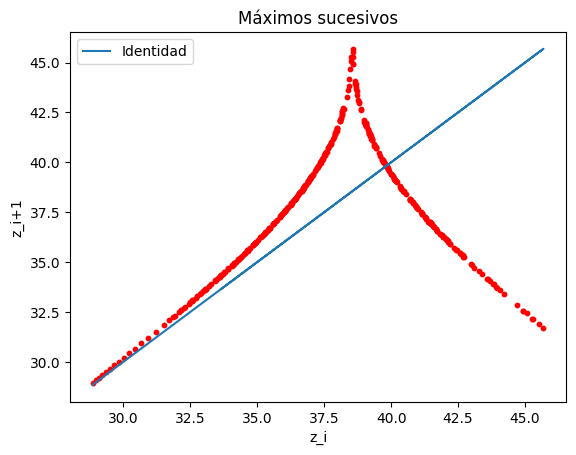

In [ ]:
# 3.3)
"""
grafiquemos z_i+1 vs z_i
"""
z_ant = [max_z[i] for i in range(0, len(max_z)-1)]
z_sig = [max_z[i+1] for i in range(0, len(max_z)-1)]

plt.plot(z_ant, z_ant, label='Identidad') # grafico la identidad
plt.scatter(z_ant, z_sig, c= 'r', s=10)
plt.xlabel("z_i")
plt.ylabel("z_i+1")
plt.title('Máximos sucesivos')
plt.legend()
plt.show()

In [ ]:
# Esto me permite ir iterando

## Ejercicio 4)

**1)** Con la intención de imitar un set de datos, agregue ruido Gaussiano de varianza $\sigma^2=1$ a la curva $z(t)$ vs $t$ generada en el inciso **1)** del ejercicio **3)**. Llamaremos a esta nueva curva $\tilde{z}(t)$ vs $t$. Grafíquela.

**2)** Utilice algún algoritmo de suavizado de curvas (ver función `savgol_filter` de la librería `scipy.signal`) para suavizar $\tilde{z}(t)$ vs $t$. Llame $\hat{z}(t)$ vs $t$ a la curva suavizada.

**3)** Utilice la curva suavizada del inciso **2)** para identificar los tiempos $\hat{t}_1$,$\hat{t}_2$,...,$\hat{t}_n$ en los cuales ocurre los máximos locales $\hat{z}_1=\hat{z}(\hat{t}_1)$, $\hat{z}_2=\hat{z}(\hat{t}_2)$, ...,$\hat{z}_n=\hat{z}(\hat{t}_n)$ correspondientes.

Calcule además los valores de la curva sin suavizar en dichos tiempos, i.e. calcule $\tilde{z}_1=\tilde{z}(\hat{t_1})$, $\tilde{z}_2=\tilde{z}(\hat{t_2})$, ..., $\tilde{z}_n=\tilde{z}(\hat{t_n})$.

**4)** Grafique la curva suavizada $\tilde{z}(t)$ vs $t$.

Agregue al gráfico los máximos $(\tilde{z}_i,\hat{t}_i)$ con puntos azules, y los máximos $(\hat{z}_i,\hat{t}_i)$ con puntos rojos.

Que observa?

**5)** Grafique $\tilde{z}_{i+1}$ vs $\tilde{z}_i$ para todo $i\in\{1,2,...,n-1\}$.

**6)** Grafique $\hat{z}_{i+1}$ vs $\hat{z}_i$ para todo $i\in\{1,2,...,n-1\}$.

**7)** Comparando los resultados de los incisos **5)** y **6)** con los del gráfico del inciso **3)** del ejercicio **3)**.

Discuta y comente.

In [ ]:
# 4.1)
"""
vamos a agregar ruido a z con varianza igual a 1. sigma * np.random.randn(...) + mu. uso media = z
"""

# juan usa np.random.normal()

tdata = t3
zdata = [z3[i] + 1.0*np.random.randn() for i in range(0, len(z3))]

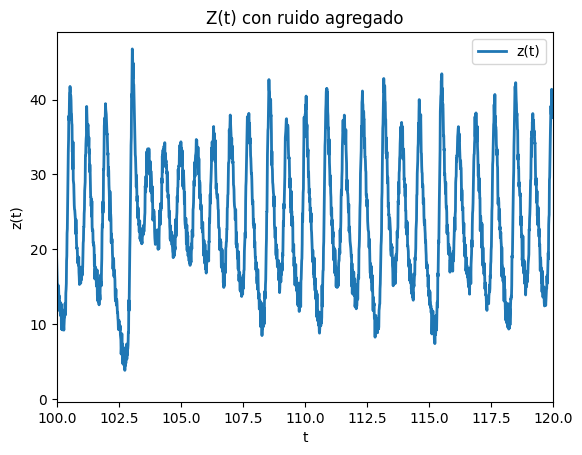

In [ ]:
"""
ploteamos zdata(t)
"""
plt.plot(tdata, zdata, label="z(t)", linewidth=2)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title('Z(t) con ruido agregado')
plt.xlim(100, 120) # achico el limite para que se pueda ver
plt.legend()
plt.show()

In [ ]:
# 4.2)

z_s = sgn.savgol_filter(zdata, 60, 3) # 35 y 3 son los datos que usó juan pero con 35 me daba medio raro
t_s = tdata

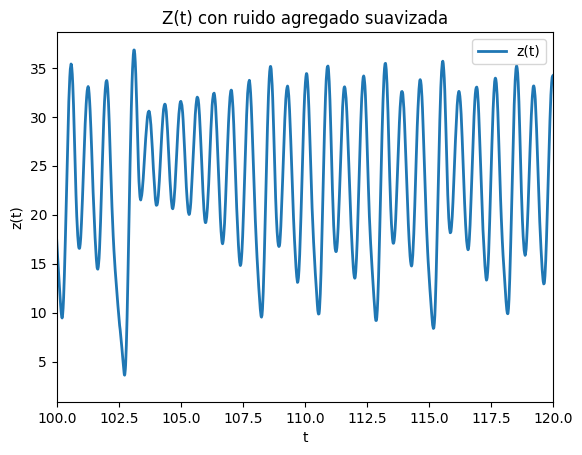

In [ ]:
"""
ploteamos z_s(t)
"""
plt.plot(t_s, z_s, label="z(t)", linewidth=2)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title('Z(t) con ruido agregado suavizada')
plt.xlim(100, 120) # achico el limite para que se pueda ver
plt.legend()
plt.show()

In [ ]:
# 4.3)
"""
Veamos los tiempos en los que ocurren los máximos locales de esta funcion suavizada
"""

max_t_s = [t_s[i] for i in range(1, len(z_s)-1) if z_s[i]>z_s[i-1] and z_s[i]>z_s[i+1]] # valor t del maximo local
max_z_s = [z_s[i] for i in range(1, len(z_s)-1) if z_s[i]>z_s[i-1] and z_s[i]>z_s[i+1]] # valor z suavizado del maximo local

# calculemos ademas los valores de la curva sin suavizar en dichos tiempos
max_zdata = [zdata[i] for i in range(1, len(z_s)-1) if z_s[i]>z_s[i-1] and z_s[i]>z_s[i+1]] # valor z sin suavizar del maximo local

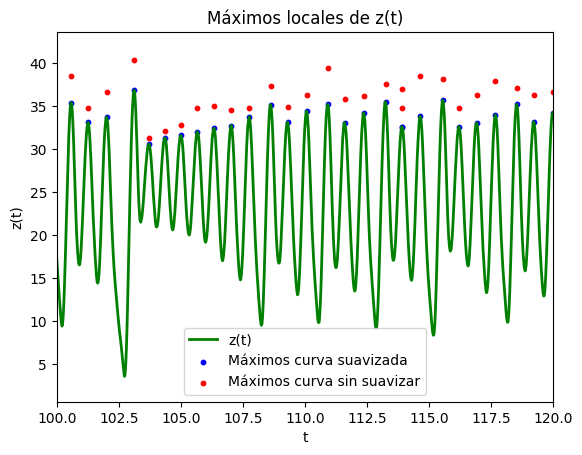

In [ ]:
"""
ahora podemos hacer el gráfico de z_s vs t mostrando los maximos
"""

plt.plot(t_s, z_s, label="z(t)", linewidth=2, c='g')
plt.scatter(max_t_s, max_z_s, label='Máximos curva suavizada', c='b', s=10)
plt.scatter(max_t_s, max_zdata, label='Máximos curva sin suavizar', c='r', s=10)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.xlim(100, 120)
plt.title('Máximos locales de z(t)')
plt.legend()
plt.show()

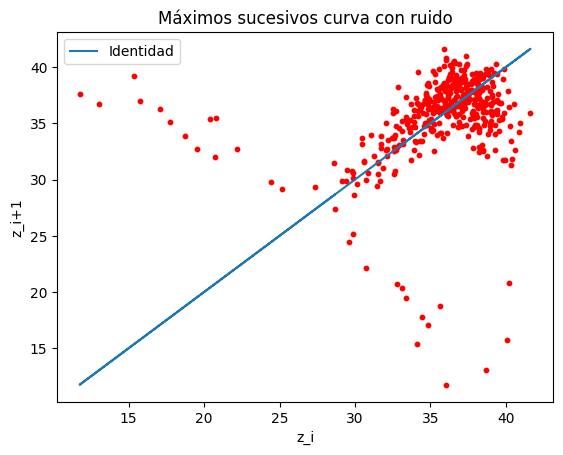

In [ ]:
# 4.5)
"""
grafiquemos z_i+1 vs z_i sin suavizar
"""
zdata_ant = [max_zdata[i] for i in range(0, len(max_zdata)-1)]
zdata_sig = [max_zdata[i+1] for i in range(0, len(max_zdata)-1)]

plt.plot(zdata_ant, zdata_ant, label='Identidad') # grafico la identidad
plt.scatter(zdata_ant, zdata_sig, c= 'r', s=10)
plt.xlabel("z_i")
plt.ylabel("z_i+1")
plt.title('Máximos sucesivos curva con ruido')
plt.legend()
plt.show()

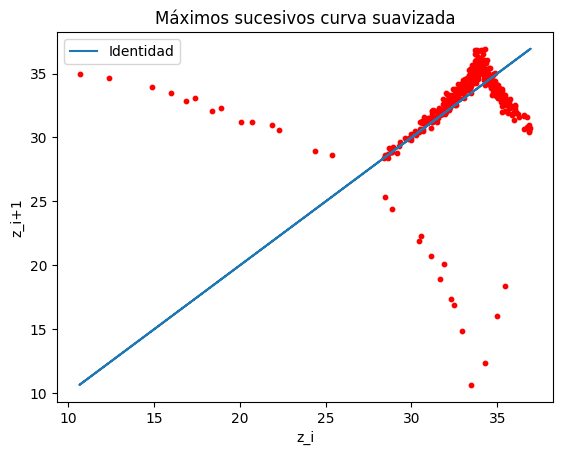

In [ ]:
# 4.6)
"""
grafiquemos z_i+1 vs z_i en la curva suavizada
"""
z_s_ant = [max_z_s[i] for i in range(0, len(max_z_s)-1)]
z_s_sig = [max_z_s[i+1] for i in range(0, len(max_z_s)-1)]

plt.plot(z_s_ant, z_s_ant, label='Identidad') # grafico la identidad
plt.scatter(z_s_ant, z_s_sig, c= 'r', s=10)
plt.xlabel("z_i")
plt.ylabel("z_i+1")
plt.title('Máximos sucesivos curva suavizada')
plt.legend()
plt.show()

**Discusión:** A partir de experimentos en los que obtenemos gráficos con ruido podemos suavizarlos y llegar a un mapa que iterando podemos obtener las ecuaciones